In [1]:
# Libraries
import numpy as np
import re
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
import networkx as nx
from adjustText import adjust_text

import gc
import re
import random
import math

import stringdb
import string
import logging

import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import Normalize, LinearSegmentedColormap

import igraph as ig
import leidenalg

In [2]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/notebooks/Post-hoc_Analysis


In [20]:
gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_go = pd.read_excel("../../PASNet/Output/GO/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/GO/pt_fixed.xlsx", index_col=0)

sc1_go.columns = pt.columns
sc1_go.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_go.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_go = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_go = df_go[df_go['Weight'] != 0]

gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_rest = pd.read_excel("../../PASNet/Output/REST/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/REST/pt_fixed.xlsx", index_col=0)

sc1_rest.columns = pt.columns
sc1_rest.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_rest.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_rest = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_rest = df_rest[df_rest['Weight'] != 0]

df = pd.concat([df_go, df_rest], ignore_index=True)
df['source'] = df['source'].str.replace(r' (\(GO|WP|R-HSA).*$', '', regex=True)

pasnet_genes = df['target'].unique()
len(pasnet_genes)

362

In [27]:
filtered_df = df[df["target"].str.contains("vdr", case=False, na=False)]

In [28]:
filtered_df

,source,target,Weight
18,"DNA-templated transcription, initiation",VDR,0.149393
515,negative regulation of cellular macromolecule ...,VDR,2.232115
548,negative regulation of cellular process,VDR,2.031342
555,negative regulation of epithelial cell prolife...,VDR,-0.287554
572,negative regulation of keratinocyte proliferation,VDR,-0.464555
585,negative regulation of macromolecule metabolic...,VDR,-0.537966
629,negative regulation of nucleic acid-templated ...,VDR,2.319974
687,negative regulation of transcription by RNA po...,VDR,1.893268
750,"negative regulation of transcription, DNA-temp...",VDR,1.705563
1156,positive regulation of transcription by RNA po...,VDR,-1.553912


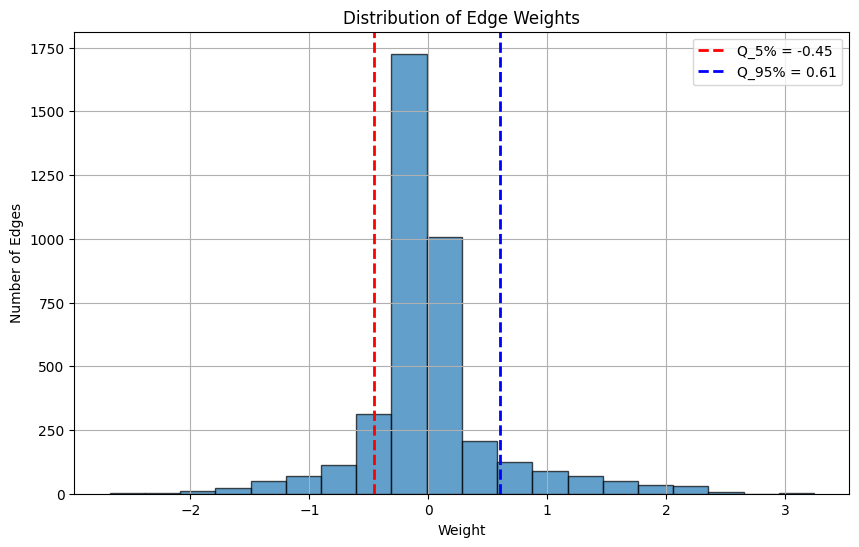

In [5]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df and has a 'Weight' column
weight_values = df['Weight']

# Calculate Q1 and Q3
q1 = weight_values.quantile(0.1)
q3 = weight_values.quantile(0.90)

plt.figure(figsize=(10, 6))
plt.hist(weight_values, bins=20, edgecolor='black', alpha=0.7)

# Add vertical lines for Q1 and Q3
plt.axvline(x=q1, color='red', linestyle='--', linewidth=2, label=f'Q_5% = {q1:.2f}')
plt.axvline(x=q3, color='blue', linestyle='--', linewidth=2, label=f'Q_95% = {q3:.2f}')

plt.title('Distribution of Edge Weights')
plt.xlabel('Weight')
plt.ylabel('Number of Edges')
plt.grid(True)
plt.legend()
plt.show()

In [6]:
df = df[(df['Weight'] > 0.61) | (df['Weight'] < -0.45)]

In [7]:
#Harmonizing with the SJARACNe file format that is to follow
genes_list = pd.concat([df['source'], df['target']]).unique().tolist()

df['MI'] = None
df['spearman'] = None
df['p-value'] = None

/tmp/ipykernel_1752/4110540120.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MI'] = None
/tmp/ipykernel_1752/4110540120.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['spearman'] = None
/tmp/ipykernel_1752/4110540120.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vi

In [8]:
df_sj_sig = pd.read_csv("../../results/ICGC/SJARACNe_networks/output_sig_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_tf = pd.read_csv("../../results/ICGC/SJARACNe_networks/output_tf_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_nc = pd.read_csv("../../results/ICGC/SJARACNe_networks/output_nc_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')

# Row binding the two dataframes
df_sj = pd.concat([df_sj_sig, df_sj_tf, df_sj_nc], axis=0, ignore_index=True)

# Removing duplicates based on columns "source" and "target"
df_sj = df_sj.drop_duplicates(subset=['source', 'target'])

# Keep only the specified columns: source, label, MI, spearman, p-value
columns_to_keep = ['source', 'target', 'MI', 'spearman', 'p-value']
df_sj = df_sj[columns_to_keep]

#Harmonizing with PASNet outputs
df_sj['Weight'] = None
df_sj = df_sj[df_sj['p-value'] <= 0.05]

df_sj['sorted_pair'] = df_sj.apply(lambda row: tuple(sorted([row['source'], row['target']])), axis=1)
df_sj = df_sj.sort_values(by='MI', ascending=False).drop_duplicates(subset=['sorted_pair']).drop(columns=['sorted_pair'])

combined_df_net = pd.concat([df, df_sj], ignore_index=True)
len(combined_df_net)

/tmp/ipykernel_1752/2525885695.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df_net = pd.concat([df, df_sj], ignore_index=True)


395617